<class 'pandas.core.frame.DataFrame'>
Index: 480 entries, 1 to 515
Data columns (total 4 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   region           480 non-null    object 
 1   year             480 non-null    int64  
 2   welfare_percent  480 non-null    float64
 3   region_standard  480 non-null    object 
dtypes: float64(1), int64(1), object(2)
memory usage: 18.8+ KB
None

Missing values by column:
 region             0
year               0
welfare_percent    0
region_standard    0
dtype: int64

Number of unique regions: 80
Number of unique years: 6

Welfare share statistics:
 count    480.000000
mean      20.469375
std        5.315063
min        4.700000
25%       16.500000
50%       21.350000
75%       24.225000
max       35.100000
Name: welfare_percent, dtype: float64

Number of duplicates: 0

Number of outliers: 1

Top-5 observations:
                   region_standard  year  welfare_percent
473          Чеченская 

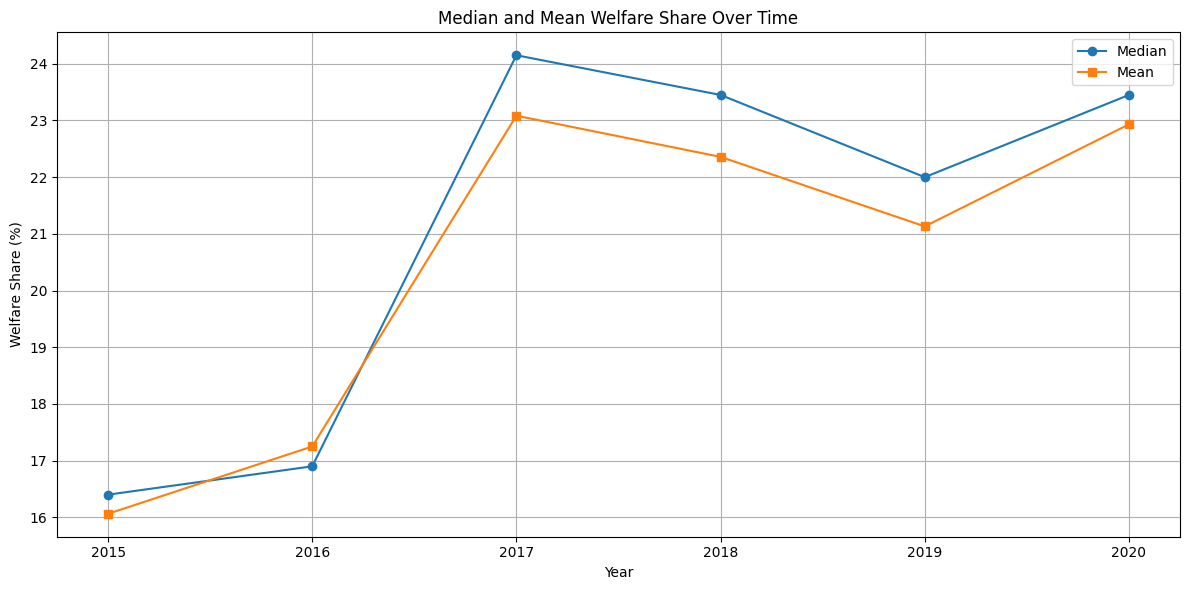

<Figure size 1600x600 with 0 Axes>

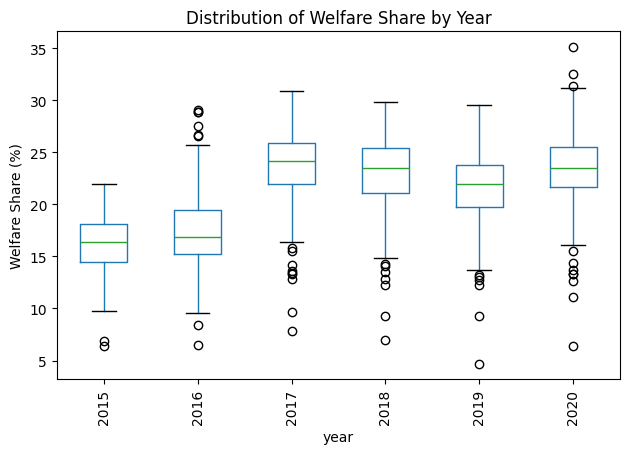

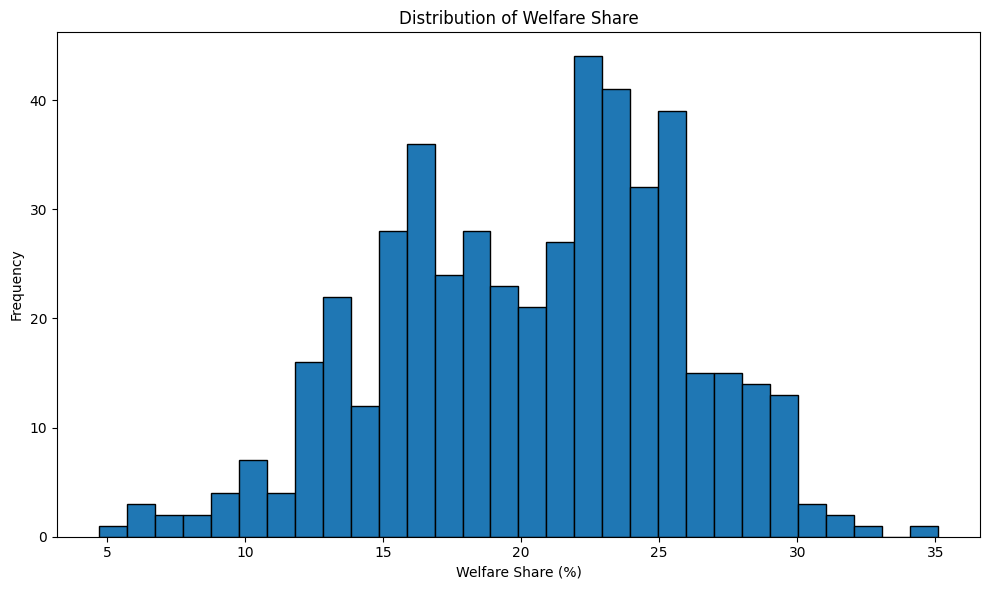

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Load data
file_path = "../../outputs/standardized_datasets/welfare_standardized.csv"
df = pd.read_csv(file_path)

# 2. Keep only rows with standardized region names
df = df[df["region_standard"].notna()]

# 3. Check data types and missing values
print(df.info())
print("\nMissing values by column:\n", df.isnull().sum())

# 4. Unique regions and years
print("\nNumber of unique regions:", df["region_standard"].nunique())
print("Number of unique years:", df["year"].nunique())

# 5. Summary statistics
print("\nWelfare share statistics:\n", df["welfare_percent"].describe())

# 6. Check duplicates
duplicates = df.duplicated().sum()
print("\nNumber of duplicates:", duplicates)

# 7. Outliers (IQR)
Q1 = df["welfare_percent"].quantile(0.25)
Q3 = df["welfare_percent"].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df[
    (df["welfare_percent"] < lower_bound) |
    (df["welfare_percent"] > upper_bound)
]
print("\nNumber of outliers:", outliers.shape[0])

# 8. Top-5 values
top5 = df.sort_values(by="welfare_percent", ascending=False).head(5)
print("\nTop-5 observations:\n", top5[["region_standard", "year", "welfare_percent"]])

# 9. Median and mean trends
median_welfare = df.groupby("year")["welfare_percent"].median()
mean_welfare = df.groupby("year")["welfare_percent"].mean()

plt.figure(figsize=(12,6))
plt.plot(median_welfare.index, median_welfare.values, marker="o", label="Median")
plt.plot(mean_welfare.index, mean_welfare.values, marker="s", label="Mean")

plt.title("Median and Mean Welfare Share Over Time")
plt.xlabel("Year")
plt.ylabel("Welfare Share (%)")

plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# 10. Boxplot
plt.figure(figsize=(16,6))
df.boxplot(column="welfare_percent", by="year", grid=False, rot=90)

plt.title("Distribution of Welfare Share by Year")
plt.suptitle("")
plt.ylabel("Welfare Share (%)")

plt.tight_layout()
plt.show()

# 11. Histogram
plt.figure(figsize=(10,6))
plt.hist(df["welfare_percent"], bins=30, edgecolor="black")

plt.title("Distribution of Welfare Share")
plt.xlabel("Welfare Share (%)")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

# EDA of `welfare_standardized.csv`

## Data Description
- The dataset contains 480 observations across 80 regions.
- Time coverage: 6 years.
- Key variable: welfare share (percentage-based indicator related to social support or public spending).

---

## Data Types
- All variables are correctly formatted:
  - `year`: int64  
  - `welfare_percent`: float64  
  - `region_standard`: object  

---

## Missing Values
- No missing values are present.

---

## Duplicates
- No duplicate records were found.

---

## Summary Statistics
- Mean: ~20.5%  
- Median: ~21.4%  
- Minimum: 4.7%  
- Maximum: 35.1%  
- 75% of regions are below ~24.2%  

The distribution is relatively concentrated, with moderate variation across regions.

---

## Outliers
- Only 1 outlier detected (IQR method).  
- The lowest value corresponds to Chukotka Autonomous Okrug (~4.7%).  
- This observation is retained as it reflects real regional differences.  

---

## Top-5 Regions by Welfare Share
1. Chechen Republic (35.1%)  
2. Republic of Ingushetia (32.5%)  
3. Astrakhan Oblast (31.4%)  
4. Jewish Autonomous Oblast (31.2%)  
5. Altai Krai (30.9%)  

---

## Trends Over Time
- Median values remain relatively stable over time.  
- Mean values show a slight increase.  
- Regional differences persist, indicating structural variation in welfare-related indicators.  

---

## Distribution Patterns
- Boxplots show moderate dispersion with limited extreme values.  
- Most regions fall within the 15–25% range.  

---

## Interpretation
- Welfare share reflects regional differences in social support systems or population needs.  
- Higher values may indicate:
  - stronger reliance on social support  
  - higher levels of economic vulnerability  
  - demographic or structural factors requiring more public assistance  

- Unlike income or GRP, this variable captures the **social policy and vulnerability dimension**.  

---

## Conclusion
The dataset is clean and ready for further analysis.

Welfare share adds an important social dimension and complements economic and health indicators in clustering by reflecting regional differences in support systems and vulnerability.

In [2]:
df.to_csv("../../data/clean/welfare_AfterEDA.csv", index=False)